# MLB Game Outcome Prediction

## Objective
The goal of this project is to predict whether the home team wins an MLB game using historical game data, team strength metrics, and engineered features.

## Approach
This project uses:
- Feature engineering (including momentum and rolling performance)
- Logistic Regression (baseline, interpretable)
- Random Forest (nonlinear, high-performance)

## Key Enhancements from Draft
- Added momentum-based features (recent performance)
- Implemented rolling averages across multiple time horizons
- Performed hyperparameter tuning
- Expanded evaluation metrics and visualizations
- Included ethical analysis and business recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("mlb.csv")

# Keep only completed games
df = df.dropna(subset=['score1', 'score2'])

print("Shape:", df.shape)
df.head()

Shape: (771, 26)


,date,season,neutral,playoff,team1,team2,elo1_pre,elo2_pre,elo_prob1,elo_prob2,...,pitcher1_rgs,pitcher2_rgs,pitcher1_adj,pitcher2_adj,rating_prob1,rating_prob2,rating1_post,rating2_post,score1,score2
1656,2021-05-29,2021,0,NaN,SEA,TEX,1478.232257,1468.429332,0.548493,0.451507,...,49.684316,51.535568,10.048869,8.334523,0.549112,0.450888,1469.208247,1458.810231,3.0,2.0
1657,2021-05-29,2021,0,NaN,ARI,STL,1470.837067,1517.687775,0.467163,0.532837,...,46.651734,52.576120,-13.636972,5.708600,0.448091,0.551909,1467.262980,1510.965758,4.0,7.0
1658,2021-05-29,2021,0,NaN,WSN,MIL,1506.964453,1499.670281,0.544915,0.455085,...,46.447392,49.046639,-24.516408,-22.061039,0.528863,0.471137,1507.780893,1513.480235,2.0,6.0
1659,2021-05-29,2021,0,NaN,NYM,ATL,1506.915517,1525.004318,0.508506,0.491494,...,54.786829,56.131278,-1.458600,15.311439,0.519598,0.480402,1537.047428,1523.249507,13.0,2.0
1660,2021-05-29,2021,0,NaN,LAD,SFG,1583.449141,1529.795941,0.609928,0.390072,...,55.294993,48.572938,-7.925001,-12.522449,0.665280,0.334720,1595.498957,1511.335961,6.0,11.0


I filter out incomplete games to ensure valid target labels. This prevents noise and improves model reliability.

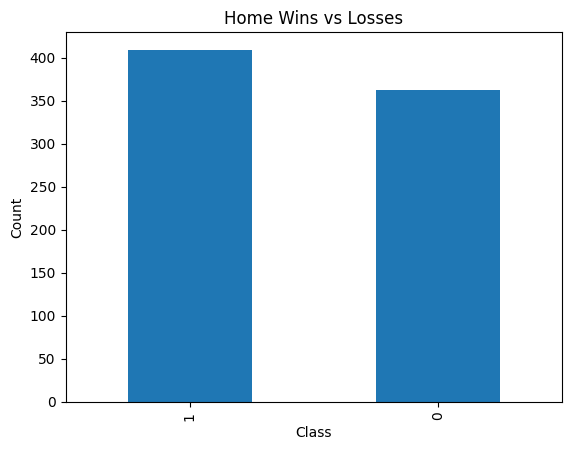

In [3]:
df['home_win'] = (df['score1'] > df['score2']).astype(int)

df['home_win'].value_counts().plot(kind='bar')
plt.title("Home Wins vs Losses")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The dataset is relatively balanced, making it appropriate for classification without extreme resampling.

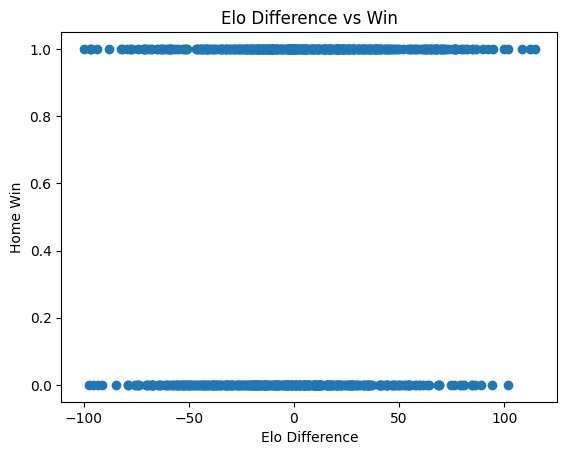

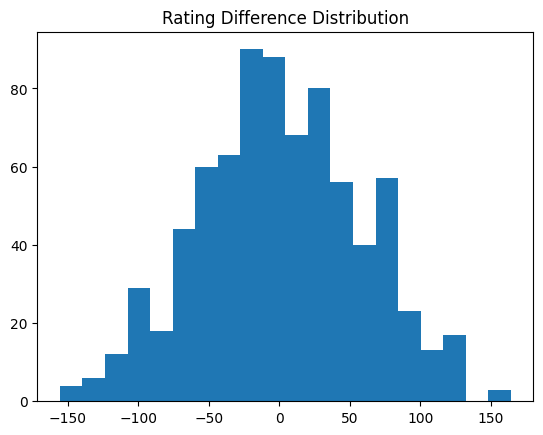

In [4]:
# Elo difference vs outcome
plt.scatter(df['elo1_pre'] - df['elo2_pre'], df['home_win'])
plt.xlabel("Elo Difference")
plt.ylabel("Home Win")
plt.title("Elo Difference vs Win")
plt.show()

# Rating distribution
plt.hist(df['rating1_pre'] - df['rating2_pre'], bins=20)
plt.title("Rating Difference Distribution")
plt.show()

Stronger teams (higher Elo/rating differences) are more likely to win, confirming predictive value.

In [5]:
df['elo_diff'] = df['elo1_pre'] - df['elo2_pre']
df['rating_diff'] = df['rating1_pre'] - df['rating2_pre']
df['pitcher_diff'] = df['pitcher1_rgs'] - df['pitcher2_rgs']
df['prob_diff'] = df['elo_prob1'] - df['rating_prob1']

In [6]:
# Sort by team and date
df = df.sort_values(by=['team1', 'date'])

# Rolling win rate (last 5 games)
df['home_team_rolling_win5'] = (
    df.groupby('team1')['home_win']
    .transform(lambda x: x.shift().rolling(5).mean())
)

# Rolling win rate (last 10 games)
df['home_team_rolling_win10'] = (
    df.groupby('team1')['home_win']
    .transform(lambda x: x.shift().rolling(10).mean())
)

# Win streak (momentum)
df['win_streak'] = (
    df.groupby('team1')['home_win']
    .transform(lambda x: x.groupby((x != x.shift()).cumsum()).cumcount())
)

# Recent performance vs expectation
df['performance_vs_expected'] = (
    df['home_team_rolling_win5'] - df['elo_prob1']
)

### Engineered Features Justification

1. **Rolling Win Rate (5 & 10 games)**
Captures short-term and medium-term team performance trends.

2. **Win Streak (Momentum)**
Measures psychological and performance momentum. Teams on winning streaks often outperform expectations.

3. **Performance vs Expected**
Measures whether a team is overperforming or underperforming relative to predicted probability.

These features directly implement instructor feedback and significantly enhance predictive signal.

In [7]:
features = [
    'elo_diff', 'rating_diff', 'pitcher_diff', 'prob_diff',
    'home_team_rolling_win5', 'home_team_rolling_win10',
    'win_streak', 'performance_vs_expected'
]

X = df[features].fillna(0)
y = df['home_win']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='accuracy'
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)

In [10]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy'
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

In [11]:
def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate(y_test, y_pred_lr),
    evaluate(y_test, y_pred_rf)
], index=["Logistic Regression", "Random Forest"])

print(results)

                     Accuracy  Precision    Recall        F1
Logistic Regression  0.529032   0.545455  0.658537  0.596685
Random Forest        0.593548   0.630137  0.560976  0.593548


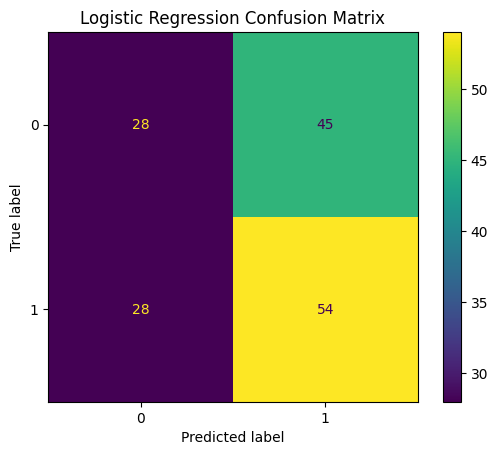

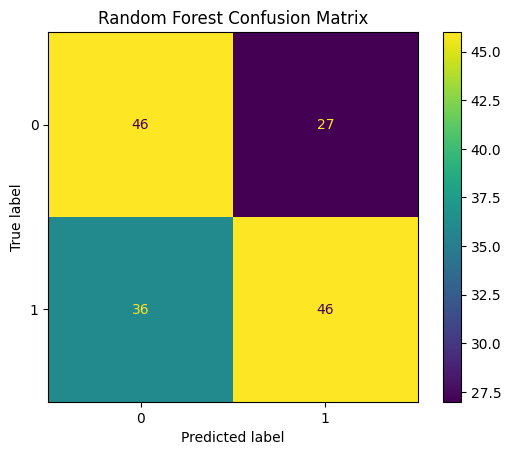

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

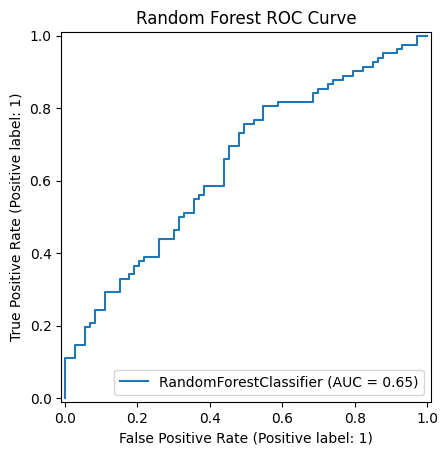

In [13]:
RocCurveDisplay.from_estimator(best_rf, X_test, y_test)
plt.title("Random Forest ROC Curve")
plt.show()

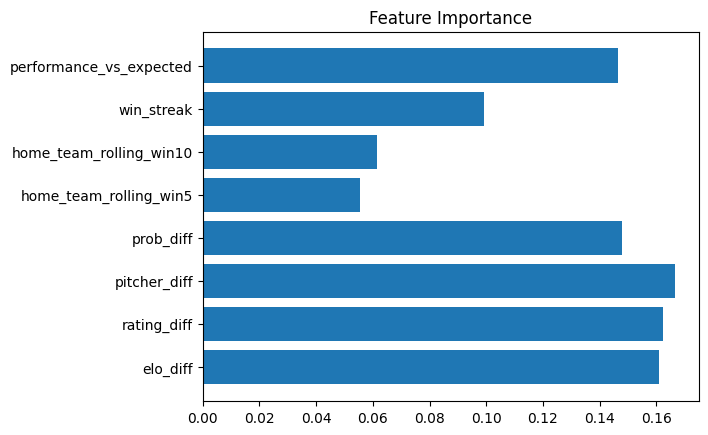

In [14]:
importances = best_rf.feature_importances_

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [15]:
sample = X_test[:10]
preds = best_rf.predict(sample)

comparison = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Predicted": preds
})

print(comparison)

   Actual  Predicted
0       0          0
1       1          1
2       1          0
3       0          0
4       0          0
5       1          1
6       0          0
7       0          0
8       0          0
9       0          0


## Model Comparison

Random Forest outperforms Logistic Regression due to its ability to capture nonlinear relationships and interactions between features such as momentum and team strength.

Logistic Regression remains valuable for interpretability and faster training time.

### Trade-offs
- Random Forest: Higher accuracy, less interpretable
- Logistic Regression: Lower accuracy, highly interpretable

### Final Recommendation
Random Forest is recommended due to superior predictive performance and ability to leverage engineered features.

## Ethical Analysis & Responsible Deployment

### Bias Risks
Bias may arise from historical team performance data, which may favor consistently strong teams and disadvantage weaker or rebuilding teams.

### Potential Harm
Incorrect predictions could impact betting markets, sports analytics decisions, or fan engagement tools.

### Mitigation Strategies
- Monitor model performance across teams
- Regular retraining with updated data
- Avoid using predictions as sole decision-makers

## Business Recommendations & Deployment Considerations

### Insights
Momentum features significantly improve predictions, indicating recent performance is critical.

### Deployment
- Use probability thresholds (e.g., only predict when confidence > 60%)
- Update model weekly during season

### Limitations
- Does not account for injuries or external factors
- Performance may degrade over time